In [1]:
# Cell 1: Imports and style configuration

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# Cell 2: CONFIG — PASTE PATHS HERE

# ============================================================
# REQUIRED INPUT FILES (all 3 databases):
# - a1_metrics_Supabase.csv
# - a1_metrics_MongoDB.csv
# - a1_metrics_AstraDB.csv
# ============================================================

# ============================================================
# EDIT THESE FOUR LINES
# ============================================================

# Full path to Supabase a1_metrics.csv
supa_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\A1\Data\a1_metrics_Supabase.csv"

# Full path to MongoDB a1_metrics.csv
mongo_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\A1\Data\a1_metrics_MongoDB.csv"

# Full path to AstraDB a1_metrics.csv
astra_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\A1\Data\a1_metrics_AstraDB.csv"

# Full path to OUTPUT FOLDER (where figures will be saved)
output_dir = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1"

# ============================================================
# DO NOT EDIT BELOW
# ============================================================

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Output filenames
fig1a_filename = os.path.join(output_dir, "fig1a_a1_warm_performance_combined.png")
fig1b_filename = os.path.join(output_dir, "fig1b_a1_tail_amplification_heatmap.png")
fig1a_outlier_filename = os.path.join(output_dir, "fig1a_outliers_a1_warm_performance.png")

print("Input files:")
print("  Supabase:", supa_csv)
print("  MongoDB:", mongo_csv)
print("  AstraDB:", astra_csv)
print("\nOutput folder:", output_dir)
print("\nFigures will be saved as:")
print("  Figure 1A:", fig1a_filename)
print("  Figure 1B:", fig1b_filename)
print("  Figure 1A Outliers (if needed):", fig1a_outlier_filename)

# Verify all inputs exist
missing = []
if not os.path.exists(supa_csv):
    missing.append("Supabase")
if not os.path.exists(mongo_csv):
    missing.append("MongoDB")
if not os.path.exists(astra_csv):
    missing.append("AstraDB")

if missing:
    print(f"\n⚠️ MISSING FILES for: {', '.join(missing)}")
    print("Please check your paths!")
else:
    print("\n✓ All input files found!")

Input files:
  Supabase: C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\A1\Data\a1_metrics_Supabase.csv
  MongoDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\A1\Data\a1_metrics_MongoDB.csv
  AstraDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\A1\Data\a1_metrics_AstraDB.csv

Output folder: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1

Figures will be saved as:
  Figure 1A: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1a_a1_warm_performance_combined.png
  Figure 1B: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1b_a1_tail_amplification_heatmap.png
  Figure 1A Outliers (if needed): C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1a_outliers_a1_warm_performance.png

✓ All input files found!


In [3]:
# Cell 3: Load all three databases' metrics and validate

# Load CSVs
df_supa = pd.read_csv(supa_csv)
df_mongo = pd.read_csv(mongo_csv)
df_astra = pd.read_csv(astra_csv)

# Required columns
required = ["query_id", "warm_p50_ms", "warm_p99_ms", "tail_amp_p99_p50"]

# Validate columns
for name, df in [("Supabase", df_supa), ("MongoDB", df_mongo), ("AstraDB", df_astra)]:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

# Sort all by query_id for consistent ordering
df_supa = df_supa.sort_values("query_id").reset_index(drop=True)
df_mongo = df_mongo.sort_values("query_id").reset_index(drop=True)
df_astra = df_astra.sort_values("query_id").reset_index(drop=True)

# Verify all have same queries
queries = df_supa["query_id"].values
if not (np.array_equal(queries, df_mongo["query_id"].values) and 
        np.array_equal(queries, df_astra["query_id"].values)):
    print("⚠️ WARNING: Databases have different query sets!")
    print("Using intersection of queries...")
    # Get common queries
    common = set(df_supa["query_id"]) & set(df_mongo["query_id"]) & set(df_astra["query_id"])
    queries = sorted(common)
    df_supa = df_supa[df_supa["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)
    df_mongo = df_mongo[df_mongo["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)
    df_astra = df_astra[df_astra["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)

print("✓ Data loaded and validated")
print(f"  Queries: {len(queries)} ({list(queries)})")
print(f"  Supabase rows: {len(df_supa)}")
print(f"  MongoDB rows: {len(df_mongo)}")
print(f"  AstraDB rows: {len(df_astra)}")

✓ Data loaded and validated
  Queries: 10 (['R1', 'R10', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9'])
  Supabase rows: 10
  MongoDB rows: 10
  AstraDB rows: 10


In [4]:
# Cell 4: Outlier Detection (Query-Level)

print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

# Combine all p99 values to compute overall statistics
all_p99 = np.concatenate([
    df_supa["warm_p99_ms"].values,
    df_mongo["warm_p99_ms"].values,
    df_astra["warm_p99_ms"].values
])
all_p50 = np.concatenate([
    df_supa["warm_p50_ms"].values,
    df_mongo["warm_p50_ms"].values,
    df_astra["warm_p50_ms"].values
])

# Overall statistics
overall_median_p50 = np.nanmedian(all_p50)
overall_median_p99 = np.nanmedian(all_p99)
overall_max_p99 = np.nanmax(all_p99)

print(f"Overall median p50: {overall_median_p50:.2f} ms")
print(f"Overall median p99: {overall_median_p99:.2f} ms")
print(f"Overall max p99: {overall_max_p99:.2f} ms")

# Detect outlier queries (any database with p99 > thresholds for that query)
outlier_queries = []
normal_queries = []

for i, q in enumerate(queries):
    # Get p99 values for this query across all databases
    q_p99_vals = [
        df_supa.iloc[i]["warm_p99_ms"],
        df_mongo.iloc[i]["warm_p99_ms"],
        df_astra.iloc[i]["warm_p99_ms"]
    ]
    max_q_p99 = np.nanmax(q_p99_vals)
    
    # Flag if ANY database shows extreme p99 for this query
    if max_q_p99 > 10 * overall_median_p50 or max_q_p99 > 5 * overall_median_p99:
        outlier_queries.append(q)
        print(f"\n🚨 OUTLIER QUERY: {q}")
        print(f"   Max p99 across DBs: {max_q_p99:.2f} ms ({max_q_p99/overall_median_p50:.1f}× median p50)")
    else:
        normal_queries.append(q)

if len(outlier_queries) > 0:
    print(f"\n✓ Detected {len(outlier_queries)} outlier query(s): {outlier_queries}")
    print(f"✓ Main figure will show {len(normal_queries)} normal queries")
    print(f"✓ Outlier figure will be generated separately")
else:
    print(f"\n✓ No extreme outliers detected")
    print(f"✓ All {len(queries)} queries in main figure")
    normal_queries = list(queries)

# Filter data for normal and outlier queries
mask_normal = [q in normal_queries for q in queries]
mask_outlier = [q in outlier_queries for q in queries]


OUTLIER DETECTION
Overall median p50: 96.00 ms
Overall median p99: 97.20 ms
Overall max p99: 413818.83 ms

🚨 OUTLIER QUERY: R10
   Max p99 across DBs: 2349.88 ms (24.5× median p50)

🚨 OUTLIER QUERY: R6
   Max p99 across DBs: 413818.83 ms (4310.8× median p50)

✓ Detected 2 outlier query(s): ['R10', 'R6']
✓ Main figure will show 8 normal queries
✓ Outlier figure will be generated separately



MAIN FIGURE GENERATION
✓ Figure 1A saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1a_a1_warm_performance_combined.png


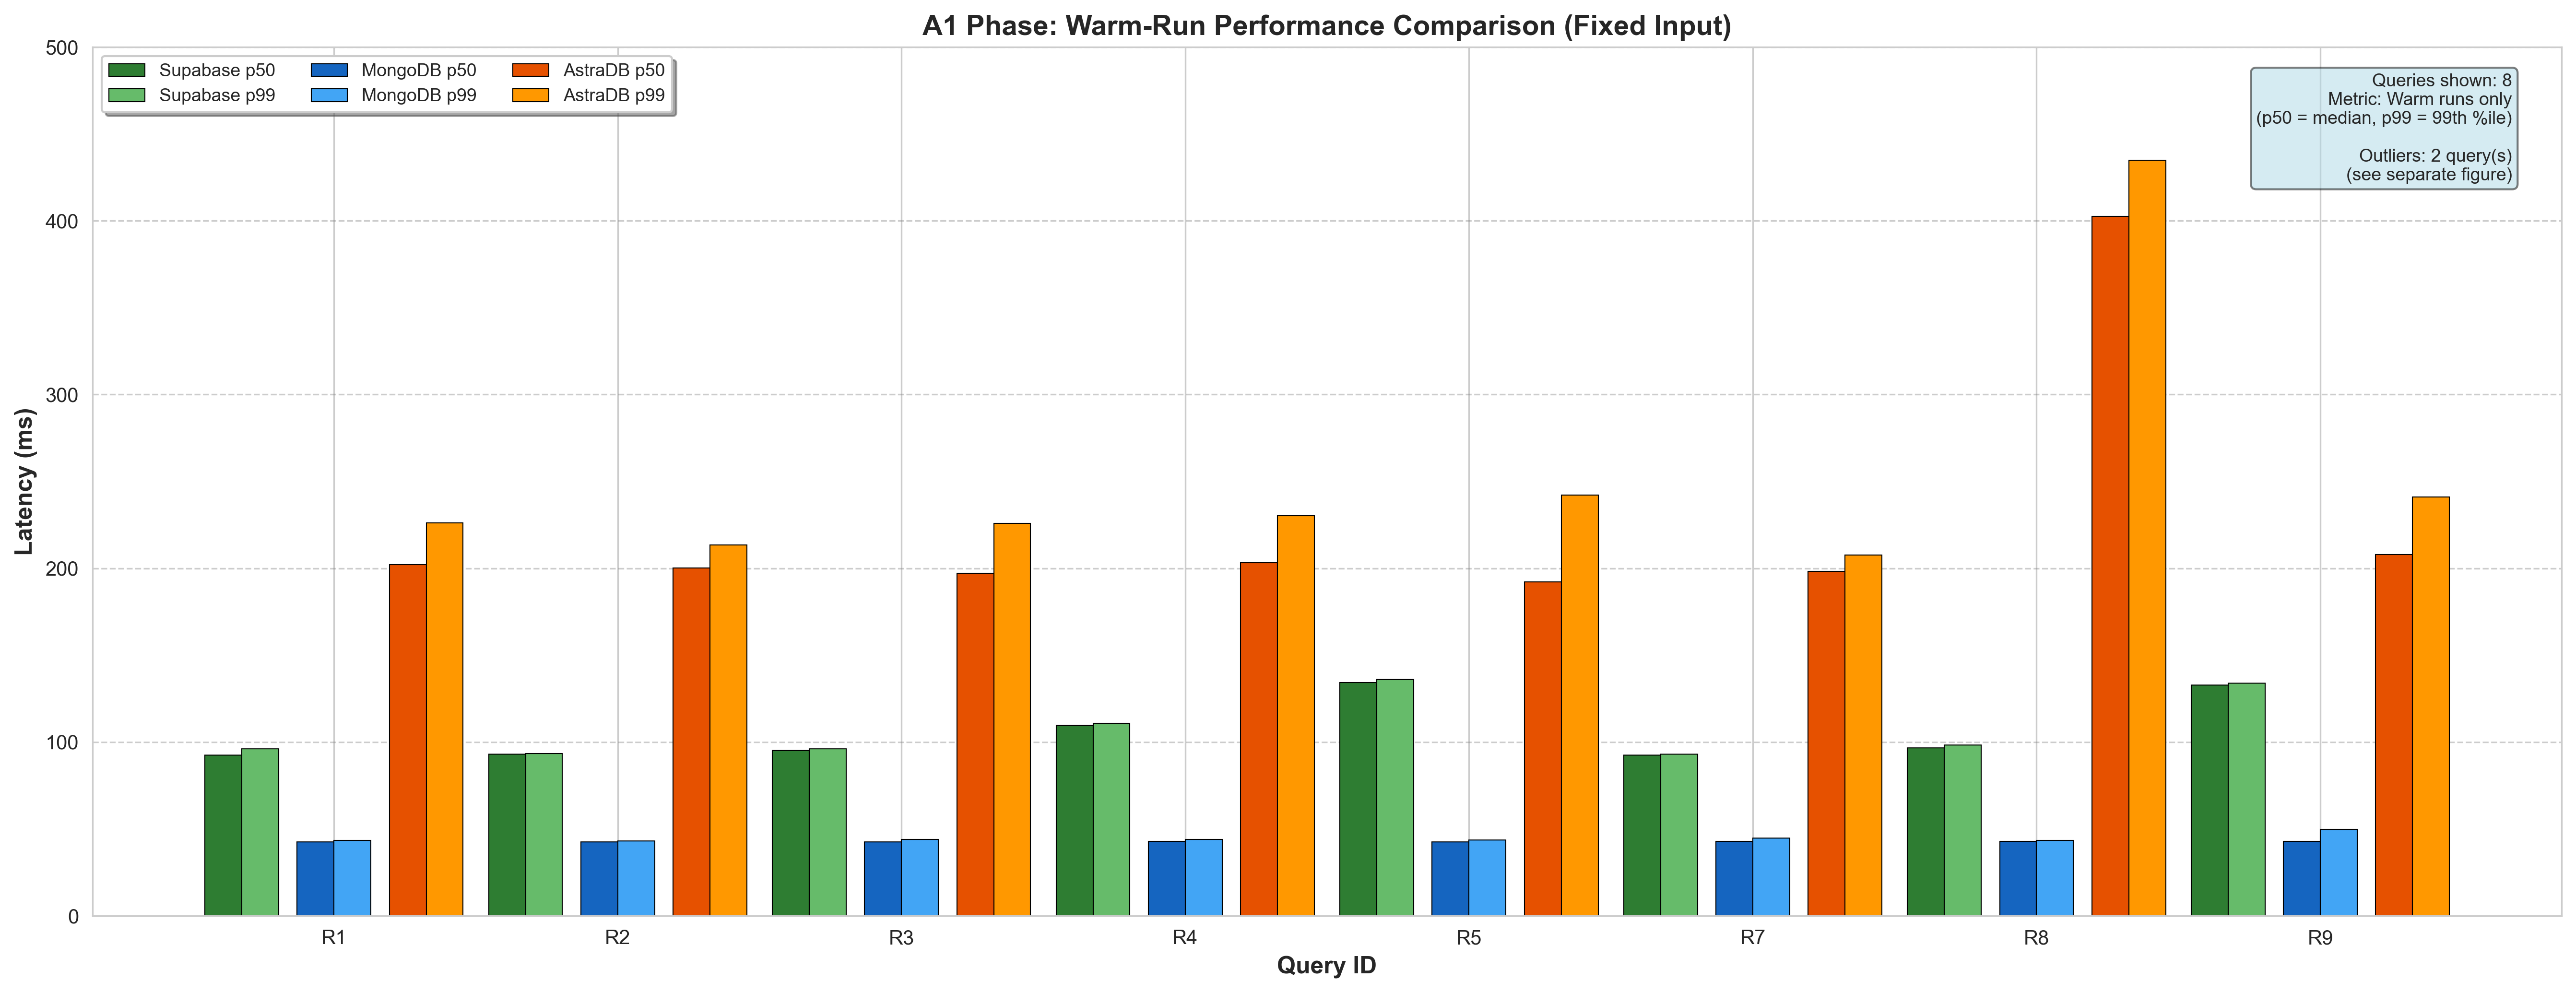

In [5]:
# Cell 5: Figure 1A - Cross-Database Warm Performance (Normal Queries)

print("\n" + "=" * 60)
print("MAIN FIGURE GENERATION")
print("=" * 60)

# Filter to normal queries
queries_normal = [q for q in queries if q in normal_queries]
n_queries_normal = len(queries_normal)

# Extract data for normal queries
supa_p50_normal = df_supa[mask_normal]["warm_p50_ms"].values
supa_p99_normal = df_supa[mask_normal]["warm_p99_ms"].values
mongo_p50_normal = df_mongo[mask_normal]["warm_p50_ms"].values
mongo_p99_normal = df_mongo[mask_normal]["warm_p99_ms"].values
astra_p50_normal = df_astra[mask_normal]["warm_p50_ms"].values
astra_p99_normal = df_astra[mask_normal]["warm_p99_ms"].values

fig, ax = plt.subplots(figsize=(18, 7))

# Bar positioning
x = np.arange(n_queries_normal)
width = 0.13
offset = width * 0.5

# Positions for each bar
pos_supa_p50 = x - 2.5*width - offset
pos_supa_p99 = x - 1.5*width - offset
pos_mongo_p50 = x - 0.5*width
pos_mongo_p99 = x + 0.5*width
pos_astra_p50 = x + 1.5*width + offset
pos_astra_p99 = x + 2.5*width + offset

# Create bars
ax.bar(pos_supa_p50, supa_p50_normal, width, 
       label='Supabase p50', color='#2E7D32', edgecolor='black', linewidth=0.5)
ax.bar(pos_supa_p99, supa_p99_normal, width, 
       label='Supabase p99', color='#66BB6A', edgecolor='black', linewidth=0.5)
ax.bar(pos_mongo_p50, mongo_p50_normal, width, 
       label='MongoDB p50', color='#1565C0', edgecolor='black', linewidth=0.5)
ax.bar(pos_mongo_p99, mongo_p99_normal, width, 
       label='MongoDB p99', color='#42A5F5', edgecolor='black', linewidth=0.5)
ax.bar(pos_astra_p50, astra_p50_normal, width, 
       label='AstraDB p50', color='#E65100', edgecolor='black', linewidth=0.5)
ax.bar(pos_astra_p99, astra_p99_normal, width, 
       label='AstraDB p99', color='#FF9800', edgecolor='black', linewidth=0.5)

# Calculate Y-axis limit with adaptive padding (normal queries only)
all_vals_normal = np.concatenate([supa_p50_normal, supa_p99_normal, mongo_p50_normal, 
                                  mongo_p99_normal, astra_p50_normal, astra_p99_normal])
max_val = np.nanmax(all_vals_normal)
min_val = np.nanmin(all_vals_normal)
y_range = max_val - min_val

if y_range < 20:
    padding = 10
elif y_range < 100:
    padding = 20
else:
    padding = max_val * 0.15

y_limit = max_val + padding

# Set axis properties
ax.set_xlabel('Query ID', fontweight='bold', fontsize=12)
ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12)
ax.set_title('A1 Phase: Warm-Run Performance Comparison (Fixed Input)', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(queries_normal, fontsize=10)
ax.set_ylim(0, y_limit)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper left', ncol=3, frameon=True, shadow=True, fontsize=9)

# Stats box
stats_text = (
    f"Queries shown: {n_queries_normal}\n"
    f"Metric: Warm runs only\n"
    f"(p50 = median, p99 = 99th %ile)"
)
if len(outlier_queries) > 0:
    stats_text += f"\n\nOutliers: {len(outlier_queries)} query(s)\n(see separate figure)"

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.savefig(fig1a_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 1A saved: {fig1a_filename}")
plt.show()


OUTLIER FIGURE GENERATION
  Using log scale (range: 42.38 to 413818.83 ms)
✓ Outlier figure saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1a_outliers_a1_warm_performance.png


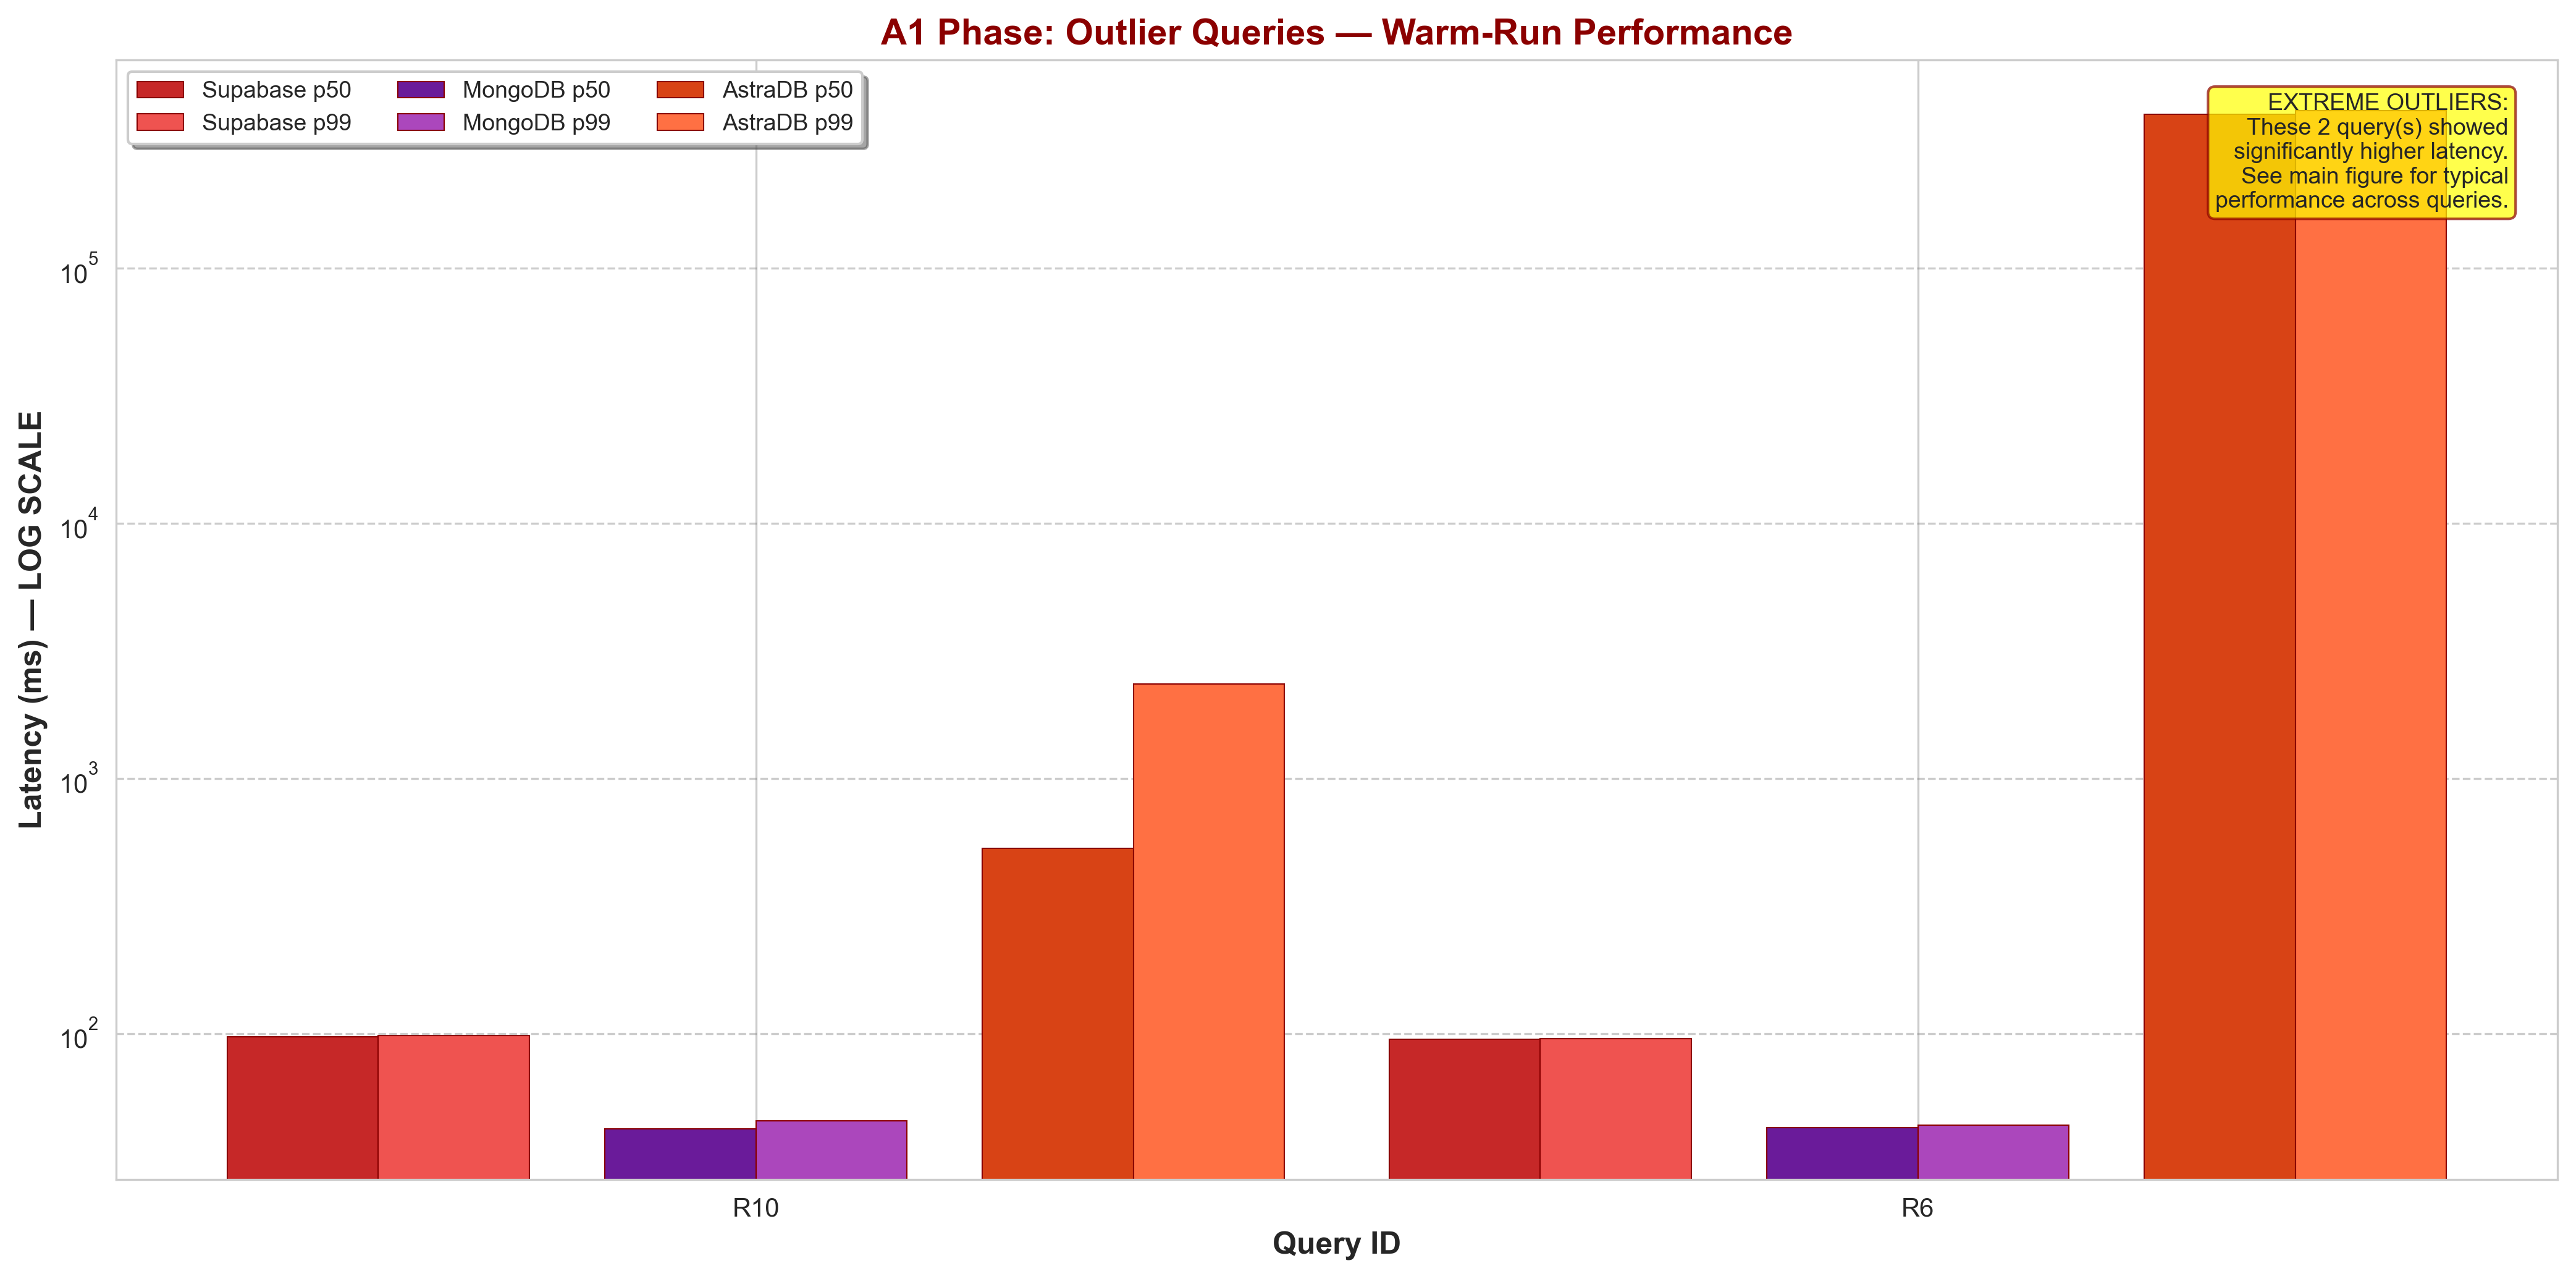

In [6]:
# Cell 6: Figure 1A Outliers - Separate visualization if outliers exist

if len(outlier_queries) > 0:
    print("\n" + "=" * 60)
    print("OUTLIER FIGURE GENERATION")
    print("=" * 60)
    
    # Filter to outlier queries
    queries_outlier = [q for q in queries if q in outlier_queries]
    n_queries_outlier = len(queries_outlier)
    
    supa_p50_outlier = df_supa[mask_outlier]["warm_p50_ms"].values
    supa_p99_outlier = df_supa[mask_outlier]["warm_p99_ms"].values
    mongo_p50_outlier = df_mongo[mask_outlier]["warm_p50_ms"].values
    mongo_p99_outlier = df_mongo[mask_outlier]["warm_p99_ms"].values
    astra_p50_outlier = df_astra[mask_outlier]["warm_p50_ms"].values
    astra_p99_outlier = df_astra[mask_outlier]["warm_p99_ms"].values
    
    fig_out, ax_out = plt.subplots(figsize=(14, 7))
    
    # Bar positioning
    x_out = np.arange(n_queries_outlier)
    width = 0.13
    offset = width * 0.5
    
    # Positions
    pos_supa_p50 = x_out - 2.5*width - offset
    pos_supa_p99 = x_out - 1.5*width - offset
    pos_mongo_p50 = x_out - 0.5*width
    pos_mongo_p99 = x_out + 0.5*width
    pos_astra_p50 = x_out + 1.5*width + offset
    pos_astra_p99 = x_out + 2.5*width + offset
    
    # Create bars (RED color scheme for outliers)
    ax_out.bar(pos_supa_p50, supa_p50_outlier, width, 
               label='Supabase p50', color='#C62828', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_supa_p99, supa_p99_outlier, width, 
               label='Supabase p99', color='#EF5350', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_mongo_p50, mongo_p50_outlier, width, 
               label='MongoDB p50', color='#6A1B9A', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_mongo_p99, mongo_p99_outlier, width, 
               label='MongoDB p99', color='#AB47BC', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_astra_p50, astra_p50_outlier, width, 
               label='AstraDB p50', color='#D84315', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_astra_p99, astra_p99_outlier, width, 
               label='AstraDB p99', color='#FF7043', edgecolor='darkred', linewidth=0.5)
    
    # Y-axis limits
    all_vals_outlier = np.concatenate([supa_p50_outlier, supa_p99_outlier, mongo_p50_outlier,
                                       mongo_p99_outlier, astra_p50_outlier, astra_p99_outlier])
    out_max = np.nanmax(all_vals_outlier)
    out_min = np.nanmin(all_vals_outlier)
    
    # Use log scale if range is extreme (>100×)
    if out_max / max(out_min, 1) > 100:
        ax_out.set_yscale('log')
        ylabel = 'Latency (ms) — LOG SCALE'
        print(f"  Using log scale (range: {out_min:.2f} to {out_max:.2f} ms)")
    else:
        ylabel = 'Latency (ms)'
        ax_out.set_ylim(0, out_max * 1.15)
    
    # Axis properties
    ax_out.set_xlabel('Query ID', fontweight='bold', fontsize=12)
    ax_out.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax_out.set_title('A1 Phase: Outlier Queries — Warm-Run Performance', 
                     fontweight='bold', fontsize=14, color='darkred')
    ax_out.set_xticks(x_out)
    ax_out.set_xticklabels(queries_outlier, fontsize=10)
    ax_out.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
    ax_out.set_axisbelow(True)
    ax_out.legend(loc='upper left', ncol=3, frameon=True, shadow=True, fontsize=9)
    
    # Warning box
    warn_text = (
        f"EXTREME OUTLIERS:\n"
        f"These {n_queries_outlier} query(s) showed\n"
        f"significantly higher latency.\n"
        f"See main figure for typical\n"
        f"performance across queries."
    )
    ax_out.text(0.98, 0.97, warn_text, transform=ax_out.transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='darkred'))
    
    plt.tight_layout()
    plt.savefig(fig1a_outlier_filename, dpi=300, bbox_inches='tight')
    print(f"✓ Outlier figure saved: {fig1a_outlier_filename}")
    plt.show()
else:
    print("\n✓ No outliers detected — skipping outlier figure")


HEATMAP GENERATION
✓ Figure 1B saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1\fig1b_a1_tail_amplification_heatmap.png


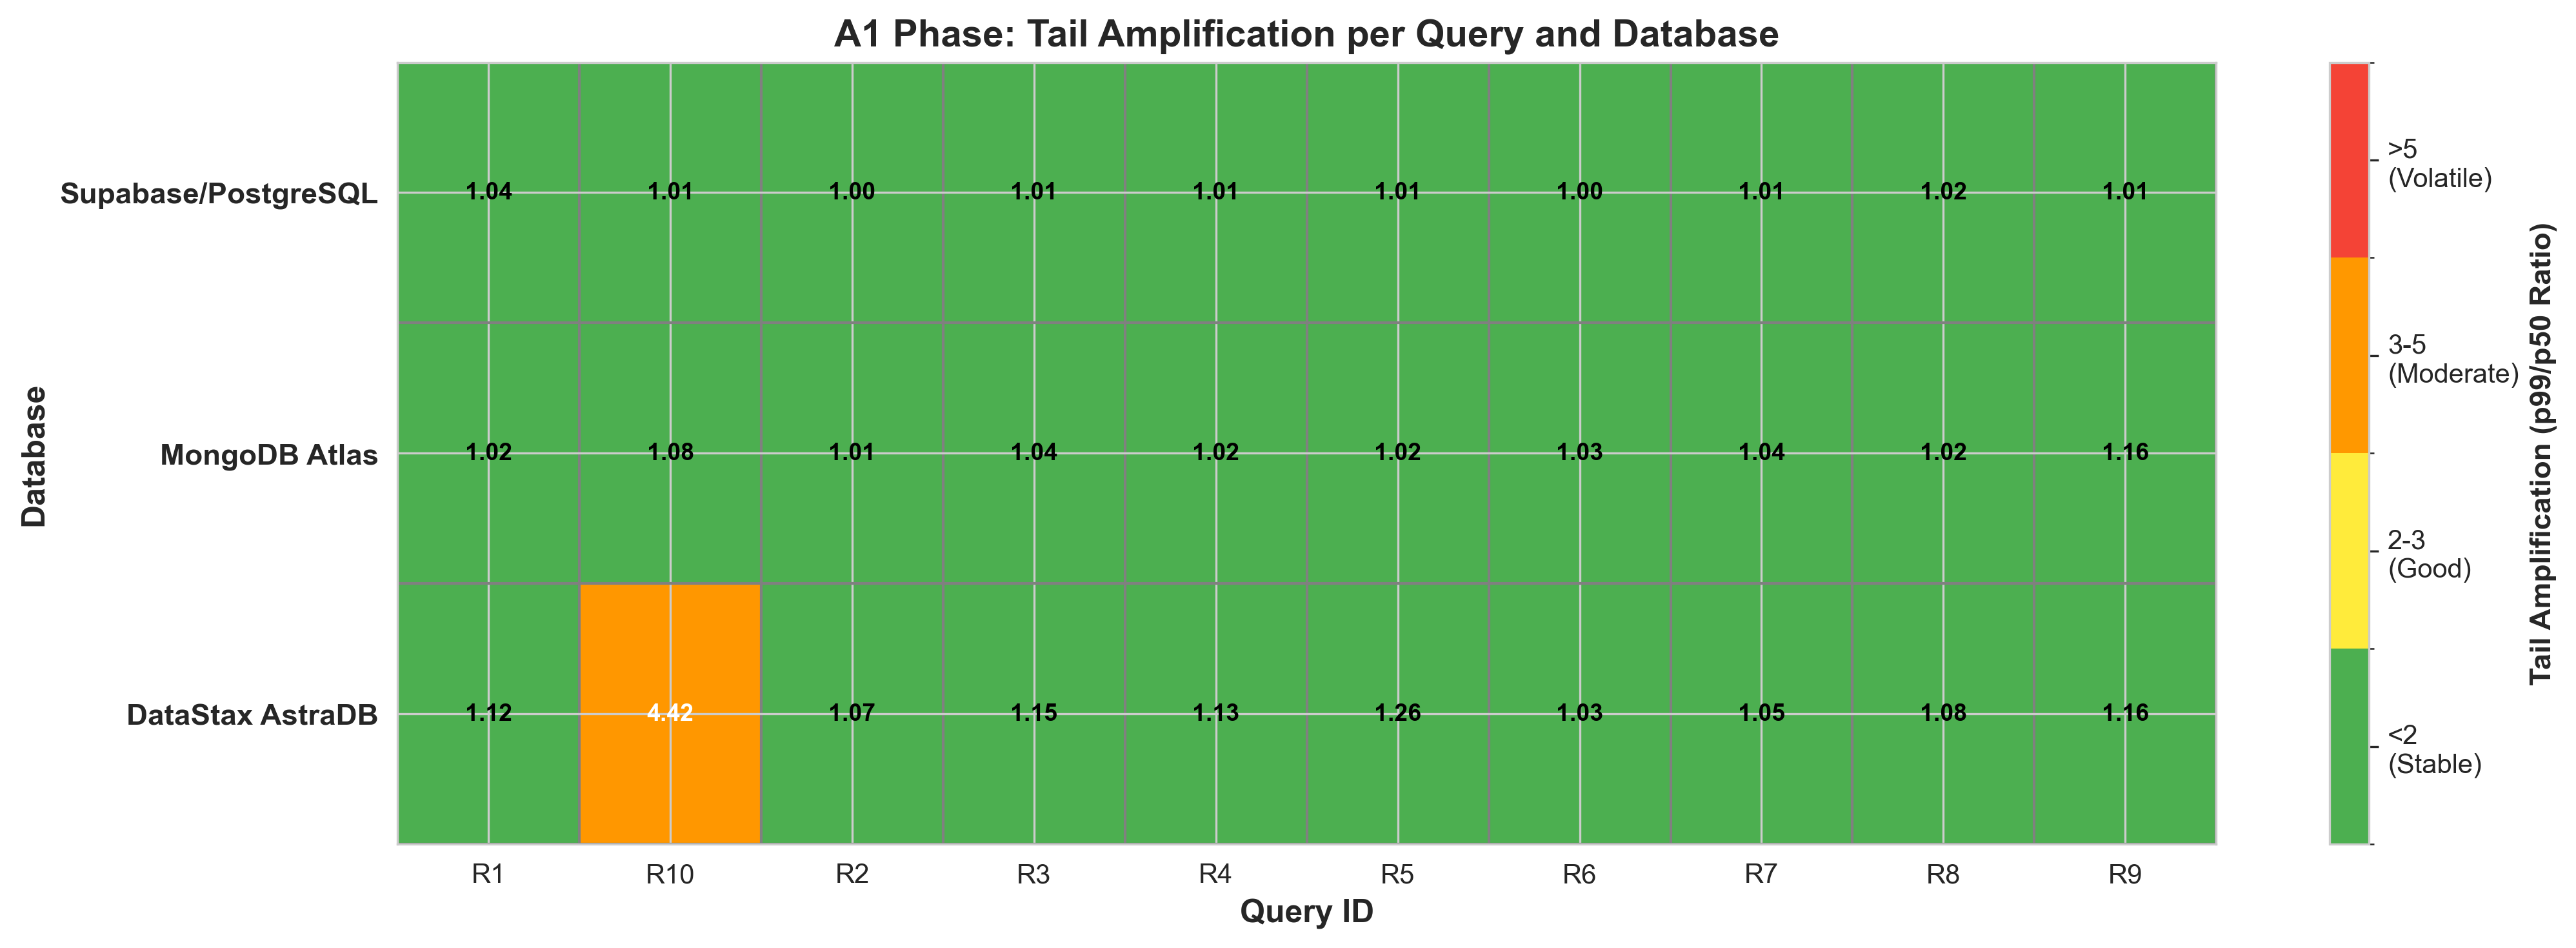

In [7]:
# Cell 7: Figure 1B - Tail Amplification Heatmap (ALL queries)

print("\n" + "=" * 60)
print("HEATMAP GENERATION")
print("=" * 60)

# Prepare data for heatmap (3 rows = DBs, columns = ALL queries)
tail_amp_data = np.array([
    df_supa["tail_amp_p99_p50"].values,
    df_mongo["tail_amp_p99_p50"].values,
    df_astra["tail_amp_p99_p50"].values
])

# Database labels
db_labels = ['Supabase/PostgreSQL', 'MongoDB Atlas', 'DataStax AstraDB']

# Create figure
fig, ax = plt.subplots(figsize=(14, 5))

# Define color boundaries: <2 green, 2-3 yellow, 3-5 orange, >5 red
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

colors = ['#4CAF50', '#FFEB3B', '#FF9800', '#F44336']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('tail_amp', colors, N=n_bins)

bounds = [0, 2, 3, 5, 10]
norm = BoundaryNorm(bounds, cmap.N, clip=True)

# Cap values at 10 for visualization
tail_amp_display = np.minimum(tail_amp_data, 10)

# Create heatmap
im = ax.imshow(tail_amp_display, cmap=cmap, norm=norm, aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(queries)))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(queries, fontsize=10)
ax.set_yticklabels(db_labels, fontsize=11, fontweight='bold')

# Add text annotations with actual values
for i in range(3):
    for j in range(len(queries)):
        val = tail_amp_data[i, j]
        if np.isnan(val):
            text = "N/A"
            color = 'black'
        elif val > 10:
            text = f"{val:.1f}↑"
            color = 'white'
        else:
            text = f"{val:.2f}"
            color = 'white' if val > 3 else 'black'
        
        ax.text(j, i, text, ha="center", va="center", 
                color=color, fontsize=9, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, ticks=[1, 2.5, 4, 7.5])
cbar.ax.set_yticklabels(['<2\n(Stable)', '2-3\n(Good)', '3-5\n(Moderate)', '>5\n(Volatile)'])
cbar.set_label('Tail Amplification (p99/p50 Ratio)', fontweight='bold', fontsize=11)

# Title and labels
ax.set_xlabel('Query ID', fontweight='bold', fontsize=12)
ax.set_ylabel('Database', fontweight='bold', fontsize=12)
ax.set_title('A1 Phase: Tail Amplification per Query and Database', 
             fontweight='bold', fontsize=14)

# Grid lines
ax.set_xticks(np.arange(len(queries)+1)-.5, minor=True)
ax.set_yticks(np.arange(4)-.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=1)
ax.tick_params(which="minor", size=0)

plt.tight_layout()
plt.savefig(fig1b_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 1B saved: {fig1b_filename}")
plt.show()

In [8]:
# Cell 8: Summary

print("\n" + "=" * 60)
print("A1 COMBINED FIGURES GENERATION COMPLETE")
print("=" * 60)

print(f"\n📊 Databases processed: Supabase, MongoDB, AstraDB")
print(f"📁 Figures saved to: {output_dir}\n")

if len(outlier_queries) > 0:
    print(f"  Figure 1A (Main): {os.path.basename(fig1a_filename)}")
    print(f"    └─ {len(normal_queries)} normal queries")
    print(f"  Figure 1A (Outliers): {os.path.basename(fig1a_outlier_filename)}")
    print(f"    └─ {len(outlier_queries)} outlier query(s): {outlier_queries}")
    print(f"  Figure 1B: {os.path.basename(fig1b_filename)}")
    print(f"    └─ Tail amplification (all queries)")
else:
    print(f"  Figure 1A: {os.path.basename(fig1a_filename)}")
    print(f"    └─ All {len(queries)} queries (no outliers)")
    print(f"  Figure 1B: {os.path.basename(fig1b_filename)}")
    print(f"    └─ Tail amplification heatmap")

print("\n✓ All figures generated successfully!")
print("\n📌 Key insights to look for:")
print("  - Figure 1A: Which database wins p50/p99 per query?")
print("  - Figure 1B: Which DB-query combos have high tail risk (red)?")
if len(outlier_queries) > 0:
    print("  - Outlier figure: Why did these queries underperform?")


A1 COMBINED FIGURES GENERATION COMPLETE

📊 Databases processed: Supabase, MongoDB, AstraDB
📁 Figures saved to: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A1

  Figure 1A (Main): fig1a_a1_warm_performance_combined.png
    └─ 8 normal queries
  Figure 1A (Outliers): fig1a_outliers_a1_warm_performance.png
    └─ 2 outlier query(s): ['R10', 'R6']
  Figure 1B: fig1b_a1_tail_amplification_heatmap.png
    └─ Tail amplification (all queries)

✓ All figures generated successfully!

📌 Key insights to look for:
  - Figure 1A: Which database wins p50/p99 per query?
  - Figure 1B: Which DB-query combos have high tail risk (red)?
  - Outlier figure: Why did these queries underperform?
